# I want to add mulple camera in single plot

In [1]:
# demo_batch_cameras.py
import torch
import math
from nerflab.camera.camera import Camera
from nerflab.camera.intrinsics import Intrinsics

# ---------- small helpers ----------
def pose_SE3(tx=0.0, ty=0.0, tz=0.0, yaw_deg=0.0, pitch_deg=0.0, roll_deg=0.0):
    """Make a simple SE(3) with ZYX Euler (deg) and translation (world frame)."""
    yd, pd, rd = map(lambda a: math.radians(a), (yaw_deg, pitch_deg, roll_deg))
    cy, sy = math.cos(yd), math.sin(yd)
    cp, sp = math.cos(pd), math.sin(pd)
    cr, sr = math.cos(rd), math.sin(rd)

    # R = Rz(yaw) @ Ry(pitch) @ Rx(roll)
    Rz = torch.tensor([[cy, -sy, 0.0],
                       [sy,  cy, 0.0],
                       [0.0, 0.0, 1.0]], dtype=torch.float32)
    Ry = torch.tensor([[ cp, 0.0, sp],
                       [0.0, 1.0, 0.0],
                       [-sp, 0.0, cp]], dtype=torch.float32)
    Rx = torch.tensor([[1.0, 0.0, 0.0],
                       [0.0,  cr, -sr],
                       [0.0,  sr,  cr]], dtype=torch.float32)
    R = Rz @ Ry @ Rx
    T = torch.eye(4, dtype=torch.float32)
    T[:3, :3] = R
    T[:3, 3] = torch.tensor([tx, ty, tz], dtype=torch.float32)
    return T


In [2]:
# 1) Two-camera batch (B=2)
H0 = pose_SE3(tx=0.0, ty=0.0, tz=0.0, yaw_deg=0)        # Cam0 at origin, facing -Z
H1 = pose_SE3(tx=1.5, ty=0.0, tz=0.5, yaw_deg=35)       # Cam1 shifted, yawed
H_wc = torch.stack([H0, H1], dim=0)                     # (B=2,4,4)
print(H_wc)

tensor([[[ 1.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  1.0000]],

        [[ 0.8192, -0.5736,  0.0000,  1.5000],
         [ 0.5736,  0.8192,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000,  0.5000],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]])


In [3]:
# 2) Intrinsics and camera
intr = Intrinsics(fx=300.0, fy=300.0, width=80, height=60)
cam = Camera(H_wc=H_wc, intr=intr, t_bounds=(0.8, 2.5), n_points_per_ray=16)
cam.print_info()

=== Camera ===
Res: 60 x 80
fx, fy: 300.00, 300.00
cx, cy: 40.00, 30.00
t_bounds: [0.8, 2.5]
H_wc shape: (2, 4, 4)
Batch size: 2


In [4]:
# 3) Generate full-grid rays (batched)
O, D = cam.get_rays(frame="world", step=4)              # (B, R, 3)
print(f"O shape {O.shape}, D shape {D.shape}")          # expect (2, R, 3)

O shape torch.Size([2, 300, 3]), D shape torch.Size([2, 300, 3])


In [5]:
# 3a) Quick sanity: each batch's origins == that camera's t_wc (broadcast)
t_wc = cam.H_wc[:, :3, 3]                               # (B,3)
assert torch.allclose(O[0].mean(0), t_wc[0], atol=1e-5)
assert torch.allclose(O[1].mean(0), t_wc[1], atol=1e-5)

In [6]:
# 4) Sample along all rays (batched)
t_vals, deltas, Pts = cam.sample_along_rays(O, D, deterministic=True)
print(f"t_vals {t_vals.shape}, Pts {Pts.shape}")        # (B,R,N), (B,R,N,3)

t_vals torch.Size([2, 300, 16]), Pts torch.Size([2, 300, 16, 3])


In [7]:
# 5) Sample a *subset* of rays per camera using explicit (B,K) indices
B, R, _ = O.shape
K = min(40, R)                                          # pick <= R rays per pose
# Different index patterns for each camera, just to show (B,K) works:
idx0 = torch.arange(0, K)                               # first K rays for cam0
idx1 = torch.randperm(R)[:K]                            # random K rays for cam1
indices = torch.stack([idx0, idx1], dim=0)              # (B, K)

Os, Ds = cam.get_rays_sampled(indices=indices, frame="world", step=4)
print(f"sampled O {Os.shape}, D {Ds.shape}")            # (B,K,3), (B,K,3)

sampled O torch.Size([2, 40, 3]), D torch.Size([2, 40, 3])


In [8]:
# 6) Sample along those subsets
t_s, d_s, P_s = cam.sample_along_rays(Os, Ds, deterministic=False)
print(f"subset t {t_s.shape}, P {P_s.shape}")           # (B,K,N), (B,K,N,3)

subset t torch.Size([2, 40, 16]), P torch.Size([2, 40, 16, 3])


Plotting batched rays: cam_index=0


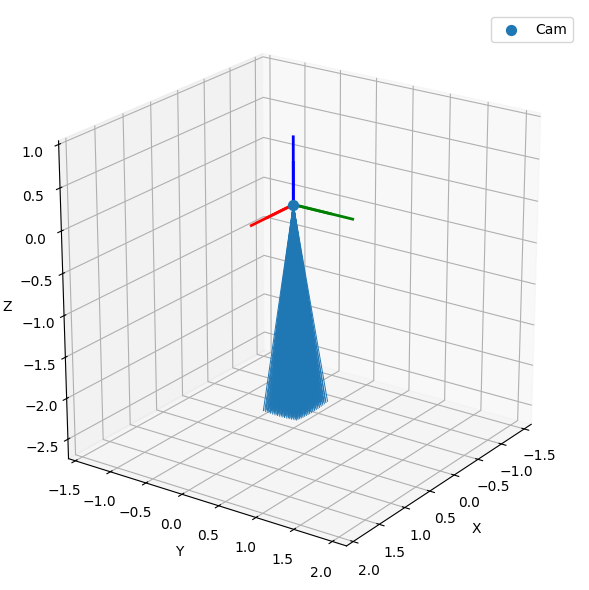

In [9]:
# 7) Plot rays/samples for cam_index=0 and cam_index=1
print("Plotting batched rays: cam_index=0")
cam.plot_rays(frame="world", step=4, mode="lines", cam_index=0)


Plotting batched rays: cam_index=1


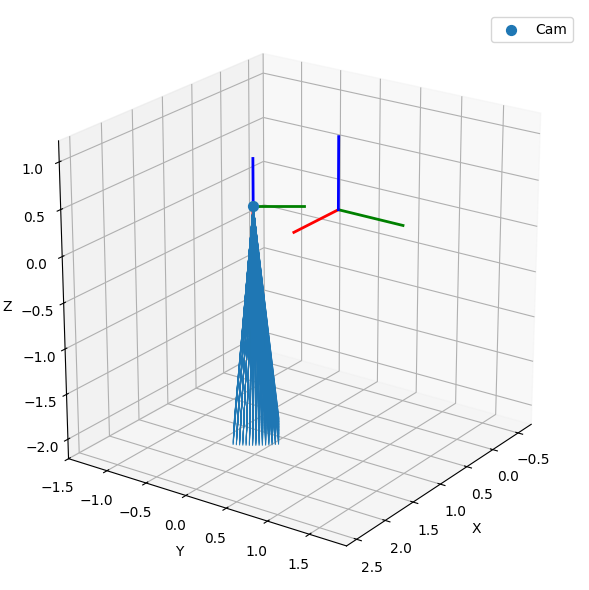

In [10]:
print("Plotting batched rays: cam_index=1")
cam.plot_rays(frame="world", step=4, mode="lines", cam_index=1)

Plotting sampled points: cam_index=0


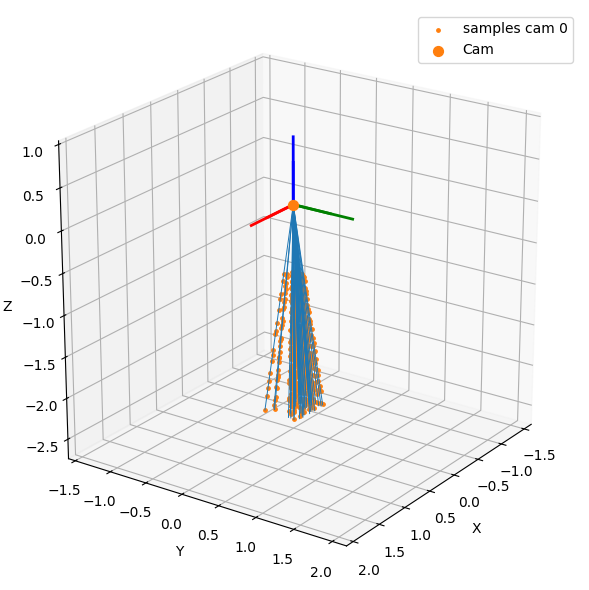

In [11]:
print("Plotting sampled points: cam_index=0")
cam.plot_samples(rays_per_pose=K, step=4, frame="world", show_rays=True, cam_index=0)

Plotting sampled points: cam_index=1


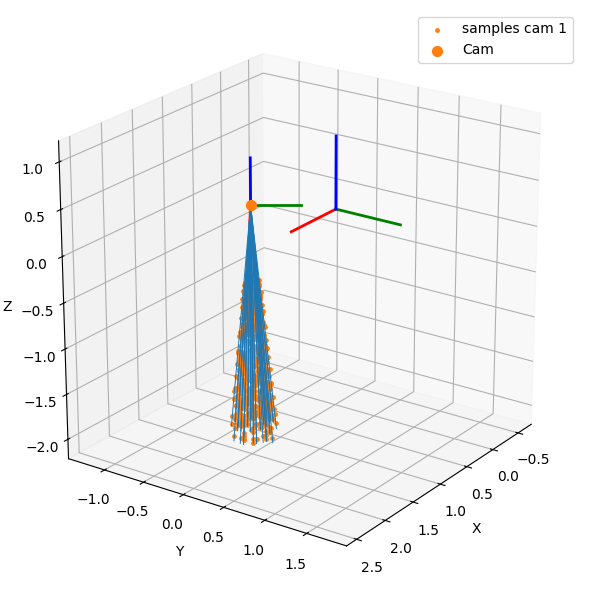

In [12]:
print("Plotting sampled points: cam_index=1")
cam.plot_samples(rays_per_pose=K, step=4, frame="world", show_rays=True, cam_index=1)

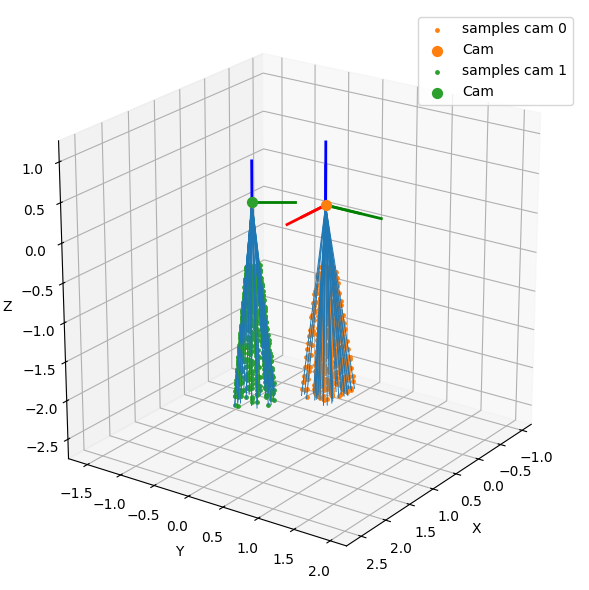

In [13]:
cam.plot_samples(rays_per_pose=K, step=4, frame="world", show_rays=True, cam_indices="all")